In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random
import os
import copy
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cuda


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create project folder
import os
save_dir = '/content/drive/MyDrive/CMPE452_Deepfake'
os.makedirs(save_dir, exist_ok=True)

print(f'Save directory: {save_dir}')

In [ ]:
# UPLOAD KAGGLE ACCESS_TOKEN
from google.colab import files
files.upload()

In [4]:
!mkdir -p ~/.kaggle && mv access_token ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
# API TEST
!kaggle datasets list | head -n 4


ref                                                              title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                   Social Media Impact on Teen Mental Health               16190  2026-04-05 08:04:21.823000          27772        593                1  
aminasalamt/amazon-tech-trends-and-sales-insights-2026           Amazon Tech Trends & Sales Insights 2026                 1997  2026-05-13 13:49:16.070000            416         22                1  


In [5]:
# UPLOAD THE DATASET, UNZIP IT AND REMOVE THE ZIP
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip -q deepfake-and-real-images.zip -d deepfake_data && rm deepfake-and-real-images.zip

Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100% 1.68G/1.68G [01:42<00:00, 17.7MB/s]



In [6]:
import os

# Count images in each class
for split in ['Train', 'Validation', 'Test']:
    for cls in ['Fake', 'Real']:
        path = f'deepfake_data/Dataset/{split}/{cls}'
        count = len(os.listdir(path))
        print(f'{split}/{cls}: {count} images')

Train/Fake: 70001 images
Train/Real: 70001 images
Validation/Fake: 19641 images
Validation/Real: 19787 images
Test/Fake: 5492 images
Test/Real: 5413 images


In [7]:
from torchvision import datasets, transforms

# Temporary transform to load dataset structure
temp_transform = transforms.Compose([transforms.ToTensor()])

# Load full training dataset
full_train = datasets.ImageFolder(
    root='deepfake_data/Dataset/Train',
    transform=temp_transform
)

# Group indices by class label
class_indices = {0: [], 1: []}
for idx, (_, label) in enumerate(full_train.samples):
    class_indices[label].append(idx)

print(f'Class 0 ({full_train.classes[0]}): {len(class_indices[0])} images')
print(f'Class 1 ({full_train.classes[1]}): {len(class_indices[1])} images')

Class 0 (Fake): 70001 images
Class 1 (Real): 70001 images


In [8]:
import random

# Take 15000 random samples from each class
random.seed(42)
subset_indices = []
for label, indices in class_indices.items():
    sampled = random.sample(indices, 15000)
    subset_indices.extend(sampled)

random.shuffle(subset_indices)
print(f'Total subset size: {len(subset_indices)}')

Total subset size: 30000


In [9]:
from torch.utils.data import random_split, Subset

# Create subset
subset = Subset(full_train, subset_indices)

# Split: 70% train, 15% val, 15% test
total = len(subset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    subset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f'Train: {len(train_set)} images')
print(f'Val:   {len(val_set)} images')
print(f'Test:  {len(test_set)} images')

Train: 21000 images
Val:   4500 images
Test:  4500 images


In [10]:
# Train transform with augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation and test transform — no augmentation
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Apply transforms
train_set.dataset.transform = train_transform
val_set.dataset.transform   = val_test_transform
test_set.dataset.transform  = val_test_transform

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

print('DataLoaders ready.')

DataLoaders ready.


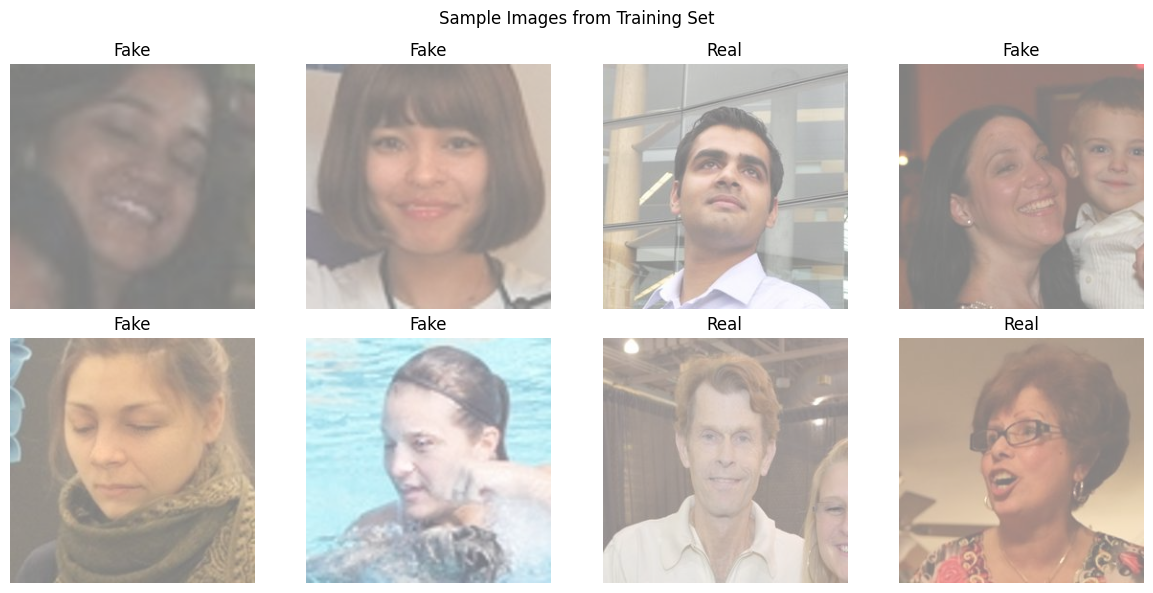

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(iter(train_loader))

# Display first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
class_names = ['Fake', 'Real']

for i, ax in enumerate(axes.flatten()):
    # Denormalize: reverse the normalize transform for display
    img = images[i].numpy().transpose(1, 2, 0)
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()])
    ax.axis('off')

plt.suptitle('Sample Images from Training Set')
plt.tight_layout()
plt.show()

In [12]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 64 * 64, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_layers(x)
        return x

# Initialize model and move to GPU
model = BaselineCNN().to(device)
print(model)

BaselineCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=262144, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [13]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Clear gradients
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()                 # Backward pass
        optimizer.step()                # Update weights

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

print('Training functions ready.')

Training functions ready.


In [14]:
# Training history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

Epoch [1/5] Train Loss: 0.6325 | Train Acc: 0.6645 | Val Loss: 0.5280 | Val Acc: 0.7453
Epoch [2/5] Train Loss: 0.5127 | Train Acc: 0.7385 | Val Loss: 0.4898 | Val Acc: 0.7531
Epoch [3/5] Train Loss: 0.4616 | Train Acc: 0.7804 | Val Loss: 0.4313 | Val Acc: 0.8036
Epoch [4/5] Train Loss: 0.4208 | Train Acc: 0.8007 | Val Loss: 0.4204 | Val Acc: 0.8047
Epoch [5/5] Train Loss: 0.3860 | Train Acc: 0.8226 | Val Loss: 0.4204 | Val Acc: 0.8098


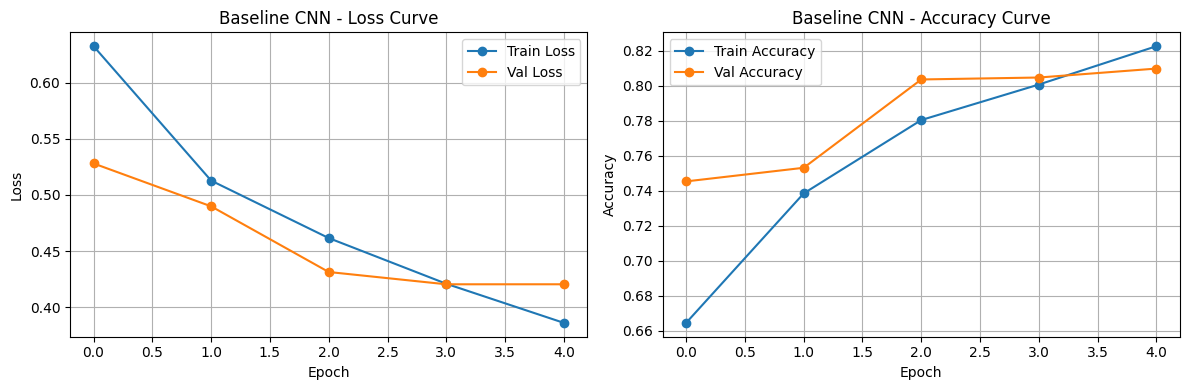

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_title('Baseline CNN - Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curve
ax2.plot(train_accs, label='Train Accuracy', marker='o')
ax2.plot(val_accs, label='Val Accuracy', marker='o')
ax2.set_title('Baseline CNN - Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [16]:
def run_experiment(config):
    """Train and evaluate a model with given hyperparameter config."""

    # Build convolutional layers dynamically
    conv_layers = []
    in_channels = 3
    out_channels = 32

    for i in range(config['num_conv_layers']):
        conv_layers += [
            nn.Conv2d(in_channels, out_channels,
                     kernel_size=config['conv_kernel_size'],
                     padding=config['conv_kernel_size']//2),
            config['activation_fn'](),
            nn.Dropout2d(config['conv_dropout']),
            nn.MaxPool2d(kernel_size=config['pool_kernel_size'],
                        stride=config['pool_stride'])
        ]
        in_channels = out_channels
        out_channels = min(out_channels * 2, 512)

    # Calculate feature map size after conv layers
    dummy = torch.zeros(1, 3, 256, 256)
    dummy_model = nn.Sequential(*conv_layers)
    dummy_out = dummy_model(dummy)
    flat_size = dummy_out.view(1, -1).shape[1]

    # Build full model
    model = nn.Sequential(
        *conv_layers,
        nn.Flatten(),
        nn.Linear(flat_size, config['fc_hidden_units']),
        config['activation_fn'](),
        nn.Dropout(config['fc_dropout']),
        nn.Linear(config['fc_hidden_units'], 2)
    ).to(device)

    # Optimizer
    if config['optimizer_type'] == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif config['optimizer_type'] == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    criterion = nn.CrossEntropyLoss()

    # DataLoader with experiment batch size
    exp_train_loader = DataLoader(train_set, batch_size=config['batch_size'],
                                  shuffle=True, num_workers=2)
    exp_val_loader   = DataLoader(val_set,   batch_size=config['batch_size'],
                                  shuffle=False, num_workers=2)

    # Training loop
    val_accs, val_losses = [], []

    for epoch in range(config['num_epochs']):
        train_one_epoch(model, exp_train_loader, optimizer, criterion)
        val_loss, val_acc = validate(model, exp_val_loader, criterion)
        val_accs.append(val_acc)
        val_losses.append(val_loss)

    return {
        'val_acc': max(val_accs),
        'val_loss': min(val_losses),
        'val_acc_curve': val_accs,
        'val_loss_curve': val_losses,
        'model': model
    }

print('Experiment function ready.')

Experiment function ready.


In [17]:
# Baseline configuration — all experiments use these values except the one being tested
baseline_config = {
    'conv_kernel_size': 3,
    'conv_dropout':     0.0,
    'activation_fn':    nn.ReLU,
    'batch_size':       32,
    'optimizer_type':   'adam',
    'num_conv_layers':  2,
    'fc_hidden_units':  128,
    'pool_kernel_size': 2,
    'pool_stride':      2,
    'fc_dropout':       0.5,
    'num_epochs':       5
}

print('Baseline config ready.')

Baseline config ready.


In [ ]:
# CONV_KERNEL_SIZE EXPERIMENT
import copy
import pandas as pd

param_name = 'conv_kernel_size'
# Values to test for conv_kernel_size
param_values = [1, 3, 5, 7, 9, 11]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    # Copy baseline, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing conv_kernel_size = 1...
  Val Acc: 0.7491 | Val Loss: 0.5012
Testing conv_kernel_size = 3...
  Val Acc: 0.8289 | Val Loss: 0.3827
Testing conv_kernel_size = 5...
  Val Acc: 0.5051 | Val Loss: 0.6931
Testing conv_kernel_size = 7...
  Val Acc: 0.5051 | Val Loss: 0.6931
Testing conv_kernel_size = 9...
  Val Acc: 0.8009 | Val Loss: 0.4238
Testing conv_kernel_size = 11...
  Val Acc: 0.5051 | Val Loss: 0.6931

Results saved. Summary:
   value   val_acc  val_loss
0      1  0.749111  0.501220
1      3  0.828889  0.382681
2      5  0.505111  0.693103
3      7  0.505111  0.693116
4      9  0.800889  0.423838
5     11  0.505111  0.693131


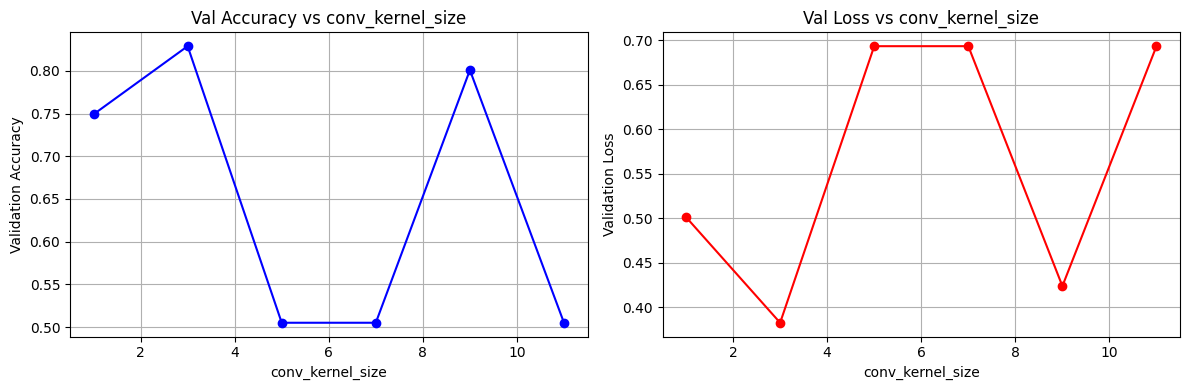

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

values = df['value'].tolist()
val_accs = df['val_acc'].tolist()
val_losses = df['val_loss'].tolist()

# Validation accuracy vs kernel size
ax1.plot(values, val_accs, marker='o', color='blue')
ax1.set_title('Val Accuracy vs conv_kernel_size')
ax1.set_xlabel('conv_kernel_size')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

# Validation loss vs kernel size
ax2.plot(values, val_losses, marker='o', color='red')
ax2.set_title('Val Loss vs conv_kernel_size')
ax2.set_xlabel('conv_kernel_size')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/conv_kernel_size_plot.png')
plt.show()

In [ ]:
###############################################################################################
# SINCE THE BEST RESULT OF CONV_KERNEL_SIZE CAME FROM THE BASELINE VALUE, WE DO NOT CHANGE IT.#
###############################################################################################

In [ ]:
# CONV_DROPOUT_SIZE EXPERIMENT
param_name = 'conv_dropout'
# Values to test for conv_dropout
param_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    # Copy the updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing conv_dropout = 0.0...
  Val Acc: 0.8209 | Val Loss: 0.3879
Testing conv_dropout = 0.1...
  Val Acc: 0.8122 | Val Loss: 0.4130
Testing conv_dropout = 0.2...
  Val Acc: 0.8018 | Val Loss: 0.4402
Testing conv_dropout = 0.3...
  Val Acc: 0.8191 | Val Loss: 0.3969
Testing conv_dropout = 0.4...
  Val Acc: 0.7940 | Val Loss: 0.4498
Testing conv_dropout = 0.5...
  Val Acc: 0.7531 | Val Loss: 0.5035

Results saved. Summary:
   value   val_acc  val_loss
0    0.0  0.820889  0.387931
1    0.1  0.812222  0.413027
2    0.2  0.801778  0.440160
3    0.3  0.819111  0.396863
4    0.4  0.794000  0.449819
5    0.5  0.753111  0.503523


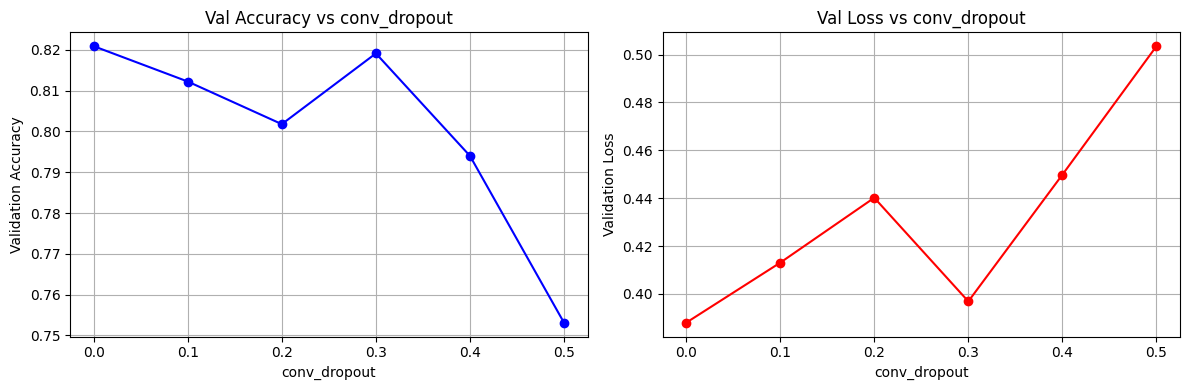

In [ ]:
df = pd.read_csv(f'{save_dir}/conv_dropout_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['value'], df['val_acc'], marker='o', color='blue')
ax1.set_title('Val Accuracy vs conv_dropout')
ax1.set_xlabel('conv_dropout')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.plot(df['value'], df['val_loss'], marker='o', color='red')
ax2.set_title('Val Loss vs conv_dropout')
ax2.set_xlabel('conv_dropout')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/conv_dropout_plot.png')
plt.show()

In [ ]:
###########################################################################################
# SINCE THE BEST RESULT OF CONV_DROPOUT CAME FROM THE BASELINE VALUE, WE DO NOT CHANGE IT.#
###########################################################################################

In [ ]:
# ACTIVATION_FN EXPERIMENT
param_name = 'activation_fn'
# Values to test for activation_fn
param_values = [nn.ReLU, nn.Tanh, nn.Sigmoid]
param_labels = ['ReLU', 'Tanh', 'Sigmoid']

results = []

for value, label in zip(param_values, param_labels):
    print(f'Testing {param_name} = {label}...')

    # Copy the updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': label,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing activation_fn = ReLU...
  Val Acc: 0.8378 | Val Loss: 0.3701
Testing activation_fn = Tanh...
  Val Acc: 0.5051 | Val Loss: 0.6950
Testing activation_fn = Sigmoid...
  Val Acc: 0.5051 | Val Loss: 0.6931

Results saved. Summary:
     value   val_acc  val_loss
0     ReLU  0.837778  0.370060
1     Tanh  0.505111  0.695022
2  Sigmoid  0.505111  0.693140


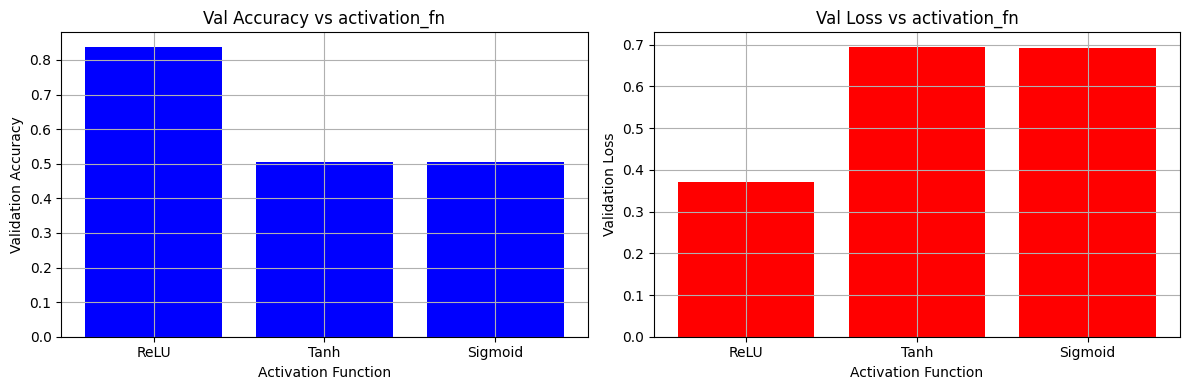

In [ ]:
df = pd.read_csv(f'{save_dir}/activation_fn_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(df['value'], df['val_acc'], color='blue')
ax1.set_title('Val Accuracy vs activation_fn')
ax1.set_xlabel('Activation Function')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.bar(df['value'], df['val_loss'], color='red')
ax2.set_title('Val Loss vs activation_fn')
ax2.set_xlabel('Activation Function')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/activation_fn_plot.png')
plt.show()
# We used bar chart since activation_fn is not numerical.

In [ ]:
############################################################################################
# SINCE THE BEST RESULT OF ACTIVATION_FN CAME FROM THE BASELINE VALUE, WE DO NOT CHANGE IT.#
############################################################################################

In [ ]:
# OPTIMIZER_TYPE EXPERIMENT
param_name = 'optimizer_type'
# Types to test for optimizer_type
param_values = ['adam', 'sgd', 'rmsprop']

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    # Copy the updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing optimizer_type = adam...
  Val Acc: 0.8224 | Val Loss: 0.4062
Testing optimizer_type = sgd...
  Val Acc: 0.7642 | Val Loss: 0.4619
Testing optimizer_type = rmsprop...
  Val Acc: 0.8280 | Val Loss: 0.3792

Results saved. Summary:
     value   val_acc  val_loss
0     adam  0.822444  0.406186
1      sgd  0.764222  0.461881
2  rmsprop  0.828000  0.379172


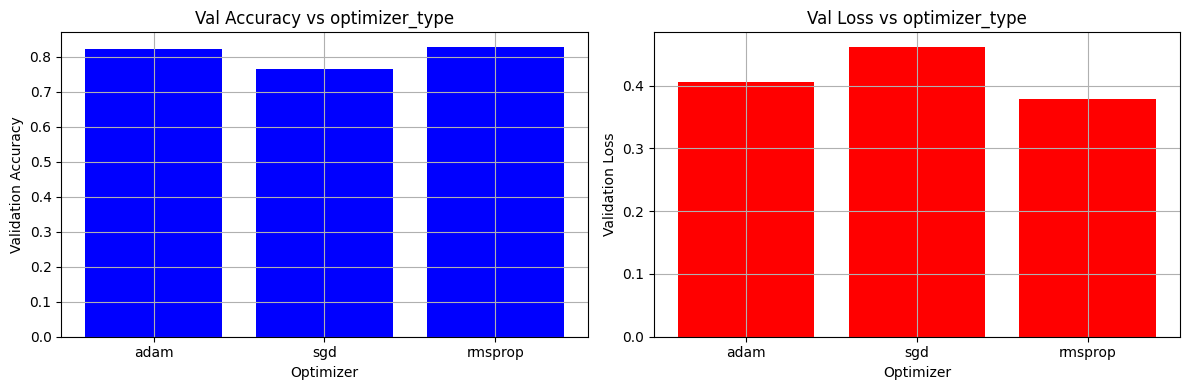

In [ ]:
df = pd.read_csv(f'{save_dir}/optimizer_type_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(df['value'], df['val_acc'], color='blue')
ax1.set_title('Val Accuracy vs optimizer_type')
ax1.set_xlabel('Optimizer')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.bar(df['value'], df['val_loss'], color='red')
ax2.set_title('Val Loss vs optimizer_type')
ax2.set_xlabel('Optimizer')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/optimizer_type_plot.png')
plt.show()

In [ ]:
###########################################################################################################
# SINCE THE BEST RESULT OF OPTIMIZER_TYPE CAME FROM THE RMSPROP, BASELINE OPTIMIZER IS UPDATED TO RMSPROP.#
###########################################################################################################
baseline_config['optimizer_type'] = 'rmsprop'

In [ ]:
# NUM_CONV_LAYERS EXPERIMENT
param_name = 'num_conv_layers'
# Values to test for num_conv_layers
param_values = [1, 2, 3, 4, 5, 6]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    # Copy the updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')
# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing num_conv_layers = 1...
  Val Acc: 0.8051 | Val Loss: 0.4255
Testing num_conv_layers = 2...
  Val Acc: 0.8349 | Val Loss: 0.3950
Testing num_conv_layers = 3...
  Val Acc: 0.7987 | Val Loss: 0.4412
Testing num_conv_layers = 4...
  Val Acc: 0.8962 | Val Loss: 0.2457
Testing num_conv_layers = 5...
  Val Acc: 0.8929 | Val Loss: 0.2617
Testing num_conv_layers = 6...
  Val Acc: 0.9151 | Val Loss: 0.2084

Results saved. Summary:
   value   val_acc  val_loss
0      1  0.805111  0.425542
1      2  0.834889  0.395044
2      3  0.798667  0.441179
3      4  0.896222  0.245723
4      5  0.892889  0.261698
5      6  0.915111  0.208360


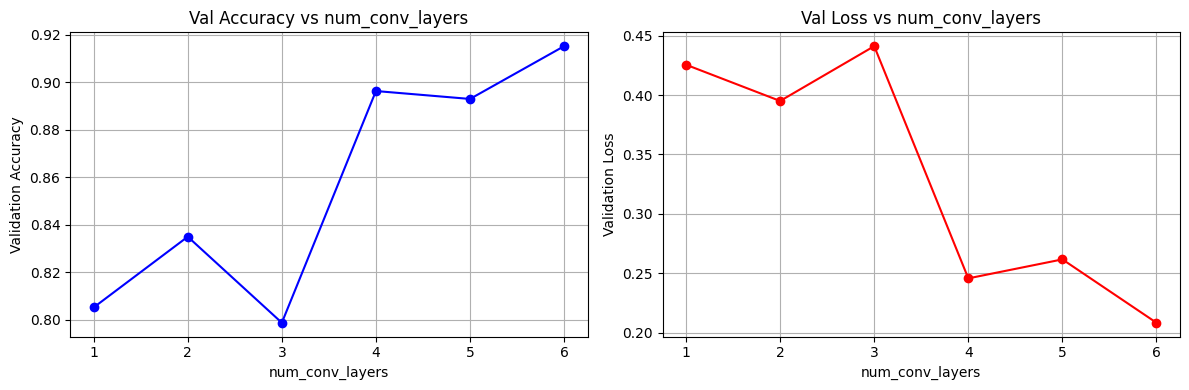

In [ ]:
df = pd.read_csv(f'{save_dir}/num_conv_layers_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['value'], df['val_acc'], marker='o', color='blue')
ax1.set_title('Val Accuracy vs num_conv_layers')
ax1.set_xlabel('num_conv_layers')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.plot(df['value'], df['val_loss'], marker='o', color='red')
ax2.set_title('Val Loss vs num_conv_layers')
ax2.set_xlabel('num_conv_layers')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/num_conv_layers_plot.png')
plt.show()

In [ ]:
######################################################################################################
# SINCE THE BEST RESULT OF NUM_CONV_LAYERS CAME FROM THE 6, BASELINE NUM_CONV_LAYERS IS UPDATED TO 6.#
######################################################################################################
baseline_config['num_conv_layers'] = 6

In [ ]:
# FC_HIDDEN_UNITS EXPERIMENT
param_name = 'fc_hidden_units'
# Values to test for fc_hidden_units
param_values = [32, 64, 128, 256, 512, 1024]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    # Copy the updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing fc_hidden_units = 32...
  Val Acc: 0.9233 | Val Loss: 0.1944
Testing fc_hidden_units = 64...
  Val Acc: 0.5051 | Val Loss: 0.6931
Testing fc_hidden_units = 128...
  Val Acc: 0.8678 | Val Loss: 0.3311
Testing fc_hidden_units = 256...
  Val Acc: 0.9193 | Val Loss: 0.2083
Testing fc_hidden_units = 512...
  Val Acc: 0.9258 | Val Loss: 0.1984
Testing fc_hidden_units = 1024...
  Val Acc: 0.9282 | Val Loss: 0.1831

Results saved. Summary:
   value   val_acc  val_loss
0     32  0.923333  0.194446
1     64  0.505111  0.693095
2    128  0.867778  0.331052
3    256  0.919333  0.208291
4    512  0.925778  0.198405
5   1024  0.928222  0.183090


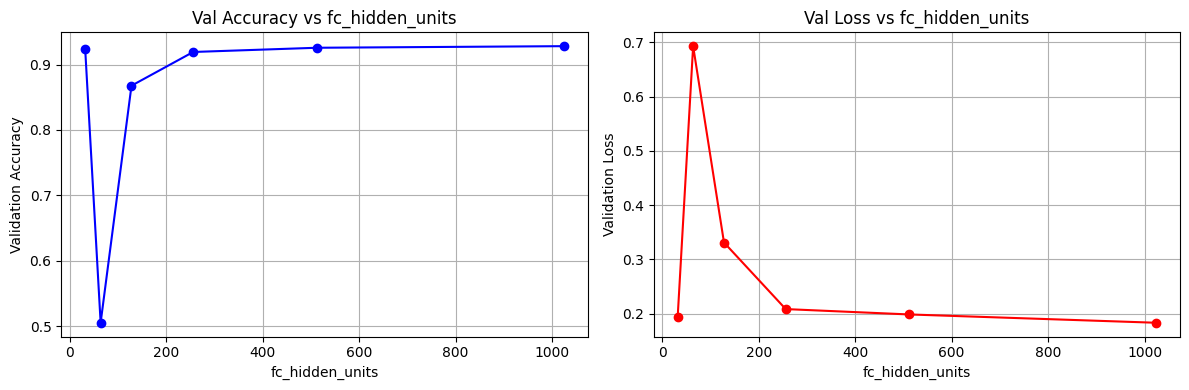

In [ ]:
df = pd.read_csv(f'{save_dir}/fc_hidden_units_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['value'], df['val_acc'], marker='o', color='blue')
ax1.set_title('Val Accuracy vs fc_hidden_units')
ax1.set_xlabel('fc_hidden_units')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.plot(df['value'], df['val_loss'], marker='o', color='red')
ax2.set_title('Val Loss vs fc_hidden_units')
ax2.set_xlabel('fc_hidden_units')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/fc_hidden_units_plot.png')
plt.show()

In [ ]:
############################################################################################################
# SINCE THE BEST RESULT OF FC_HIDDEN_UNITS CAME FROM THE 1024, BASELINE FC_HIDDEN_UNITS IS UPDATED TO 1024.#
############################################################################################################
baseline_config['fc_hidden_units'] = 1024

In [ ]:
# CHECK NEXT CELL
# POOL_KERNEL_SIZE EXPERIMENT
param_name = 'pool_kernel_size'
# Values to test for pool_kernel_size
param_values = [2, 3, 4, 5, 6, 7]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    # Copy updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing pool_kernel_size = 2...
  Val Acc: 0.5051 | Val Loss: 0.6931
Testing pool_kernel_size = 3...
  Val Acc: 0.6833 | Val Loss: 0.6020
Testing pool_kernel_size = 4...
  Val Acc: 0.9078 | Val Loss: 0.2179
Testing pool_kernel_size = 5...
  Val Acc: 0.8938 | Val Loss: 0.2601
Testing pool_kernel_size = 6...


RuntimeError: Given input size: (512x4x4). Calculated output size: (512x0x0). Output size is too small

In [ ]:
# pool_kernel_size values of 6 and 7 caused a RuntimeError due to feature map collapse.
# With 6 convolutional layers and MaxPool2d, the spatial dimensions reduce to 4x4.
# Applying a pool kernel larger than the feature map size (512x4x4) results in output size 0x0.
# Therefore, only values 2-5 are valid for this configuration.
import pandas as pd

results = [
    {'value': 2, 'val_acc': 0.5051, 'val_loss': 0.6931},
    {'value': 3, 'val_acc': 0.6833, 'val_loss': 0.6020},
    {'value': 4, 'val_acc': 0.9078, 'val_loss': 0.2179},
    {'value': 5, 'val_acc': 0.8938, 'val_loss': 0.2601},
    {'value': 6, 'val_acc': None, 'val_loss': None},
    {'value': 7, 'val_acc': None, 'val_loss': None},
]

df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/pool_kernel_size_results.csv', index=False)
print(df)



   value  val_acc  val_loss
0      2   0.5051    0.6931
1      3   0.6833    0.6020
2      4   0.9078    0.2179
3      5   0.8938    0.2601
4      6      NaN       NaN
5      7      NaN       NaN


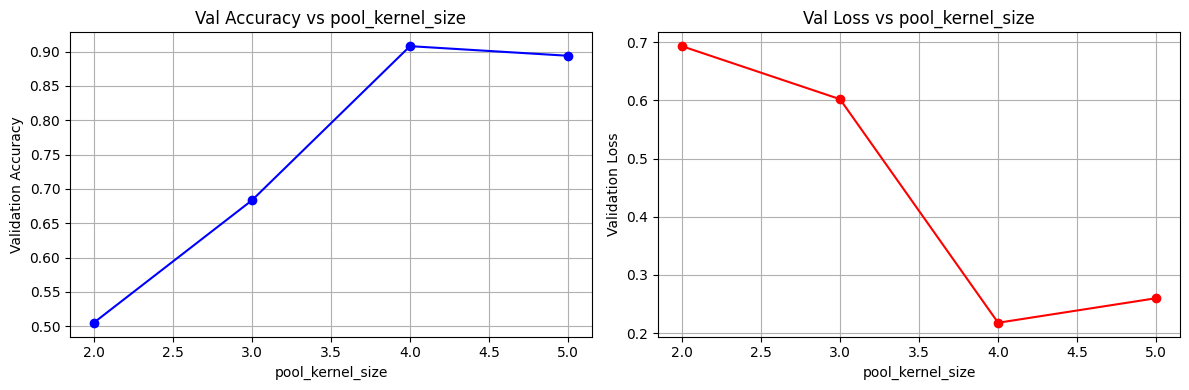

In [ ]:
df = pd.read_csv(f'{save_dir}/pool_kernel_size_results.csv')
df = df.dropna()  # Remove invalid values (6 and 7)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['value'], df['val_acc'], marker='o', color='blue')
ax1.set_title('Val Accuracy vs pool_kernel_size')
ax1.set_xlabel('pool_kernel_size')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.plot(df['value'], df['val_loss'], marker='o', color='red')
ax2.set_title('Val Loss vs pool_kernel_size')
ax2.set_xlabel('pool_kernel_size')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/pool_kernel_size_plot.png')
plt.show()

In [ ]:
########################################################################################################
# SINCE THE BEST RESULT OF POOL_KERNEL_SIZE CAME FROM THE 4, BASELINE POOL_KERNEL_SIZE IS UPDATED TO 4.#
########################################################################################################
baseline_config['pool_kernel_size'] = 4

In [ ]:
baseline_config['optimizer_type'] = 'rmsprop'
baseline_config['num_conv_layers'] = 6
baseline_config['fc_hidden_units'] = 1024
baseline_config['pool_kernel_size'] = 4

In [ ]:
# POOL_STRIDE EXPERIMENT
param_name = 'pool_stride'
# Values to test for pool_stride
param_values = [2, 3, 4, 5, 6, 7]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    try:
        # Copy the updated configs, change only this parameter
        config = copy.deepcopy(baseline_config)
        config[param_name] = value

        # Run experiment
        result = run_experiment(config)
        results.append({
            'value': value,
            'val_acc': result['val_acc'],
            'val_loss': result['val_loss']
        })
        print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

    except Exception as e:
        print(f'  Failed: {e}')
        results.append({
            'value': value,
            'val_acc': None,
            'val_loss': None
        })
# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing pool_stride = 2...
  Val Acc: 0.9053 | Val Loss: 0.2291
Testing pool_stride = 3...
  Failed: Given input size: (512x2x2). Calculated output size: (512x0x0). Output size is too small
Testing pool_stride = 4...
  Failed: Given input size: (512x1x1). Calculated output size: (512x0x0). Output size is too small
Testing pool_stride = 5...
  Failed: Given input size: (256x2x2). Calculated output size: (256x0x0). Output size is too small
Testing pool_stride = 6...
  Failed: Given input size: (256x1x1). Calculated output size: (256x0x0). Output size is too small
Testing pool_stride = 7...
  Failed: Given input size: (256x1x1). Calculated output size: (256x0x0). Output size is too small

Results saved. Summary:
   value   val_acc  val_loss
0      2  0.905333  0.229083
1      3       NaN       NaN
2      4       NaN       NaN
3      5       NaN       NaN
4      6       NaN       NaN
5      7       NaN       NaN


In [ ]:
# NOTE: With 6 conv layers and pool_kernel_size=4, only pool_stride=2 is valid.
# Higher stride values cause feature map collapse (output size 0x0).
# pool_stride=1 causes GPU OOM due to insufficient downsampling.
# Therefore, pool_stride=2 is the only viable option for this configuration.
################################################################################################
# SINCE THE ONLY VALID RESULT OF POOL_STRIDE CAME FROM THE BASELINE, BASELINE WILL NOT CHANGE. #
################################################################################################

In [ ]:
# FC_DROPOUT EXPERIMENT
param_name = 'fc_dropout'
# Values to test for fc_dropout
param_values = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    try:
        # Copy the updated configs, change only this parameter
        config = copy.deepcopy(baseline_config)
        config[param_name] = value

        # Run experiment
        result = run_experiment(config)
        results.append({
            'value': value,
            'val_acc': result['val_acc'],
            'val_loss': result['val_loss']
        })
        print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

    except Exception as e:
        print(f'  Failed: {e}')
        results.append({
            'value': value,
            'val_acc': None,
            'val_loss': None
        })

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved.')
print(df)

Testing fc_dropout = 0.0...
  Val Acc: 0.8993 | Val Loss: 0.2386
Testing fc_dropout = 0.1...
  Val Acc: 0.8560 | Val Loss: 0.3235
Testing fc_dropout = 0.2...
  Val Acc: 0.9100 | Val Loss: 0.2254
Testing fc_dropout = 0.3...
  Val Acc: 0.8540 | Val Loss: 0.3241
Testing fc_dropout = 0.5...
  Val Acc: 0.9156 | Val Loss: 0.2253
Testing fc_dropout = 0.7...
  Val Acc: 0.8751 | Val Loss: 0.3146

Results saved.
   value   val_acc  val_loss
0    0.0  0.899333  0.238611
1    0.1  0.856000  0.323515
2    0.2  0.910000  0.225444
3    0.3  0.854000  0.324131
4    0.5  0.915556  0.225265
5    0.7  0.875111  0.314603


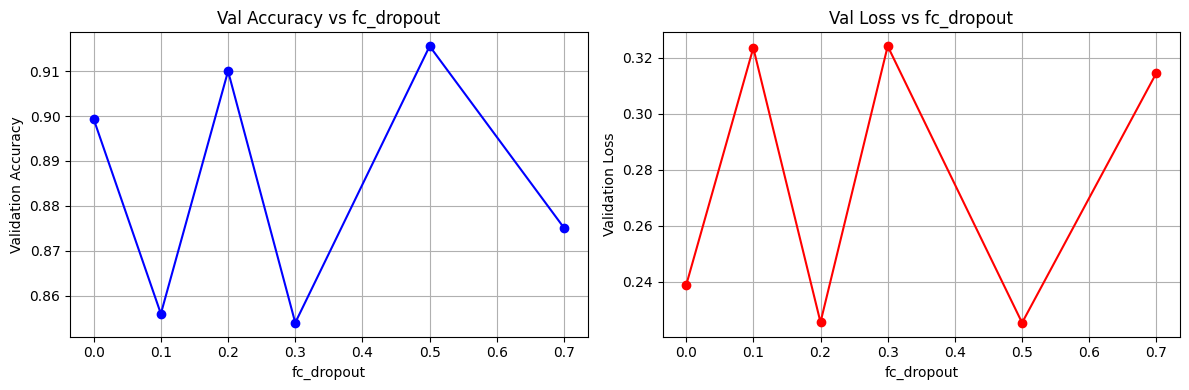

In [ ]:
df = pd.read_csv(f'{save_dir}/fc_dropout_results.csv')
df = df.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['value'], df['val_acc'], marker='o', color='blue')
ax1.set_title('Val Accuracy vs fc_dropout')
ax1.set_xlabel('fc_dropout')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.plot(df['value'], df['val_loss'], marker='o', color='red')
ax2.set_title('Val Loss vs fc_dropout')
ax2.set_xlabel('fc_dropout')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/fc_dropout_plot.png')
plt.show()

In [ ]:
#########################################################################################
# SINCE THE BEST RESULT OF FC_DROPOUT CAME FROM THE BASELINE VALUE, WE DO NOT CHANGE IT.#
#########################################################################################

In [ ]:
# NUM_EPOCHS EXPERIMENT
param_name = 'num_epochs'
# Values to test for num_epochs
param_values = [5, 10, 20, 40]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

     # Copy the updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })
    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved.')
print(df)

Testing num_epochs = 5...
  Val Acc: 0.8744 | Val Loss: 0.3114
Testing num_epochs = 10...
  Val Acc: 0.9262 | Val Loss: 0.1791
Testing num_epochs = 20...
  Val Acc: 0.5051 | Val Loss: 0.6931
Testing num_epochs = 40...
  Val Acc: 0.9480 | Val Loss: 0.1400

Results saved.
   value   val_acc  val_loss
0      5  0.874444  0.311403
1     10  0.926222  0.179110
2     20  0.505111  0.693087
3     40  0.948000  0.140024


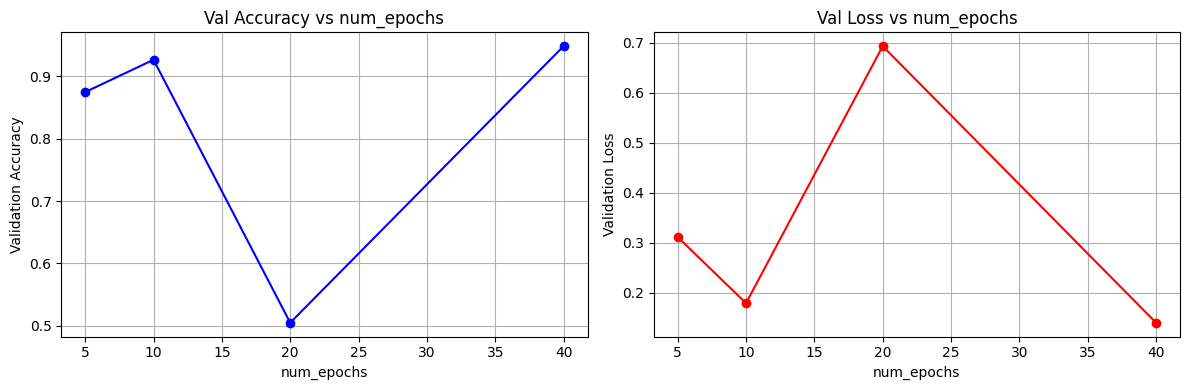

In [ ]:
df = pd.read_csv(f'{save_dir}/num_epochs_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['value'], df['val_acc'], marker='o', color='blue')
ax1.set_title('Val Accuracy vs num_epochs')
ax1.set_xlabel('num_epochs')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.plot(df['value'], df['val_loss'], marker='o', color='red')
ax2.set_title('Val Loss vs num_epochs')
ax2.set_xlabel('num_epochs')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/num_epochs_plot.png')
plt.show()

In [ ]:
##############################################################################################
# SINCE THE BEST RESULT OF NUM_EPOCHS CAME FROM THE 40, BASELINE NUM_EPOCHS IS UPDATED TO 40.#
##############################################################################################
baseline_config['num_epochs'] = 40

In [ ]:
#### SINCE CHANGING BATCH_SIZE CAN INCREASE THE TRAINING TIME SIGNIFICANTLY, THIS EXPERIMENT WAS CONDUCTED LATER RATHER THAN AS THE 4TH EXPERIMENT IN THE DEFAULT ORDER. ####
# BATCH_SIZE EXPERIMENT
param_name = 'batch_size'
# Values to test for batch_size
param_values = [8, 16, 32, 64, 128, 256]

results = []

for value in param_values:
    print(f'Testing {param_name} = {value}...')

    # Copy updated configs, change only this parameter
    config = copy.deepcopy(baseline_config)
    config[param_name] = value

    # Run experiment
    result = run_experiment(config)
    results.append({
        'value': value,
        'val_acc': result['val_acc'],
        'val_loss': result['val_loss']
    })

    print(f'  Val Acc: {result["val_acc"]:.4f} | Val Loss: {result["val_loss"]:.4f}')

# Save results to CSV
df = pd.DataFrame(results)
df.to_csv(f'{save_dir}/{param_name}_results.csv', index=False)
print(f'\nResults saved. Summary:')
print(df)

Testing batch_size = 8...
  Val Acc: 0.5051 | Val Loss: 0.6931
Testing batch_size = 16...
  Val Acc: 0.9527 | Val Loss: 0.1329
Testing batch_size = 32...
  Val Acc: 0.9507 | Val Loss: 0.1401
Testing batch_size = 64...
  Val Acc: 0.9524 | Val Loss: 0.1470
Testing batch_size = 128...
  Val Acc: 0.9551 | Val Loss: 0.1384
Testing batch_size = 256...
  Val Acc: 0.9442 | Val Loss: 0.1620

Results saved. Summary:
   value   val_acc  val_loss
0      8  0.505111  0.693091
1     16  0.952667  0.132865
2     32  0.950667  0.140093
3     64  0.952444  0.146981
4    128  0.955111  0.138415
5    256  0.944222  0.162005


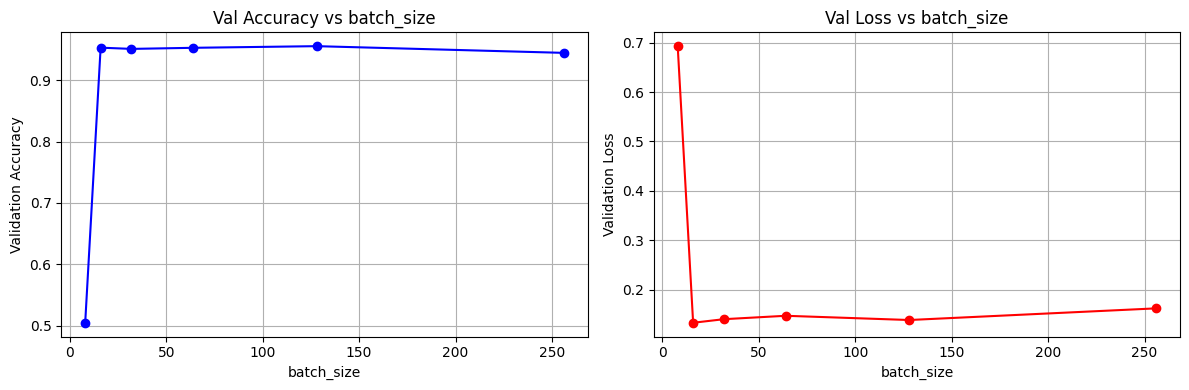

In [ ]:
df = pd.read_csv(f'{save_dir}/batch_size_results.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['value'], df['val_acc'], marker='o', color='blue')
ax1.set_title('Val Accuracy vs batch_size')
ax1.set_xlabel('batch_size')
ax1.set_ylabel('Validation Accuracy')
ax1.grid(True)

ax2.plot(df['value'], df['val_loss'], marker='o', color='red')
ax2.set_title('Val Loss vs batch_size')
ax2.set_xlabel('batch_size')
ax2.set_ylabel('Validation Loss')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/batch_size_plot.png')
plt.show()

In [ ]:
###############################################################################################
# SINCE THE BEST RESULT OF BATCH_SIZE CAME FROM THE 128, BASELINE BATCHSIZE IS UPDATED TO 128.#
###############################################################################################
baseline_config['batch_size'] = 128

In [18]:
# Best configuration from all experiments
best_config = {
    'conv_kernel_size': 3,
    'conv_dropout':     0.0,
    'activation_fn':    nn.ReLU,
    'batch_size':       128,
    'optimizer_type':   'rmsprop',
    'num_conv_layers':  6,
    'fc_hidden_units':  1024,
    'pool_kernel_size': 4,
    'pool_stride':      2,
    'fc_dropout':       0.5,
    'num_epochs':       40
}

print('Best Configuration:')
for k, v in best_config.items():
    print(f'  {k}: {v}')

Best Configuration:
  conv_kernel_size: 3
  conv_dropout: 0.0
  activation_fn: <class 'torch.nn.modules.activation.ReLU'>
  batch_size: 128
  optimizer_type: rmsprop
  num_conv_layers: 6
  fc_hidden_units: 1024
  pool_kernel_size: 4
  pool_stride: 2
  fc_dropout: 0.5
  num_epochs: 40


Training final model...
Val Acc:  0.9491
Val Loss: 0.1392
Model saved.


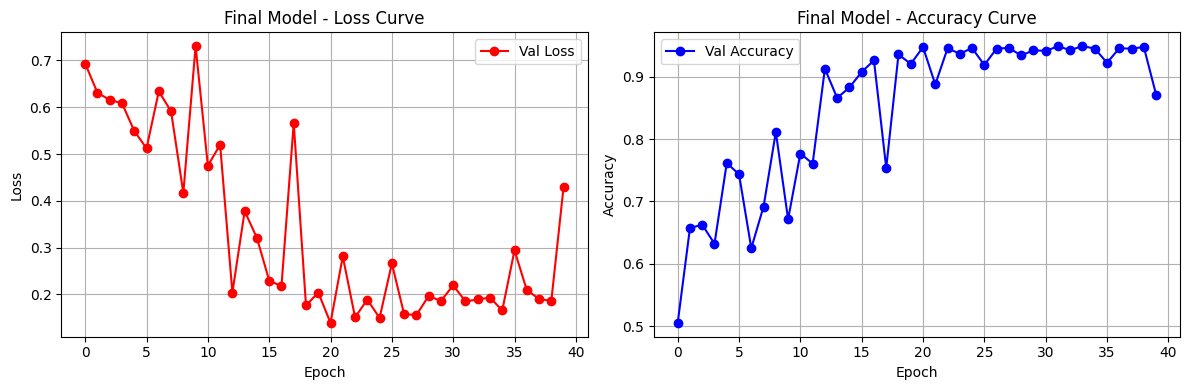

In [21]:
print('Training final model...')
final_result = run_experiment(best_config)
final_model = final_result['model']

torch.save(final_model.state_dict(), f'{save_dir}/best_model.pth')
print(f'Val Acc:  {final_result["val_acc"]:.4f}')
print(f'Val Loss: {final_result["val_loss"]:.4f}')
print('Model saved.')

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(final_result['val_loss_curve'], marker='o', color='red', label='Val Loss')
ax1.set_title('Final Model - Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(final_result['val_acc_curve'], marker='o', color='blue', label='Val Accuracy')
ax2.set_title('Final Model - Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/final_model_curves.png')
plt.show()

Test Accuracy: 0.8809

Classification Report:
              precision    recall  f1-score   support

        Fake       0.83      0.96      0.89      2237
        Real       0.96      0.80      0.87      2263

    accuracy                           0.88      4500
   macro avg       0.89      0.88      0.88      4500
weighted avg       0.89      0.88      0.88      4500



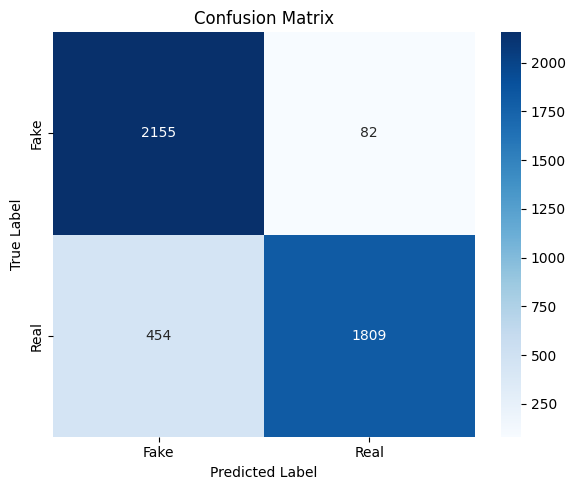

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Test evaluation
final_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = final_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f'Test Accuracy: {test_acc:.4f}')

# Classification report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{save_dir}/confusion_matrix.png')
plt.show()

In [23]:
# Retrain baseline model for test evaluation
baseline_test_config = {
    'conv_kernel_size': 3,
    'conv_dropout':     0.0,
    'activation_fn':    nn.ReLU,
    'batch_size':       32,
    'optimizer_type':   'adam',
    'num_conv_layers':  2,
    'fc_hidden_units':  128,
    'pool_kernel_size': 2,
    'pool_stride':      2,
    'fc_dropout':       0.5,
    'num_epochs':       5
}

print('Training baseline model for test evaluation...')
baseline_result = run_experiment(baseline_test_config)
baseline_model = baseline_result['model']
print(f'Baseline Val Acc: {baseline_result["val_acc"]:.4f}')

Training baseline model for test evaluation...
Baseline Val Acc: 0.8011


Baseline Test Accuracy: 0.7989

Baseline Classification Report:
              precision    recall  f1-score   support

        Fake       0.88      0.69      0.77      2237
        Real       0.75      0.90      0.82      2263

    accuracy                           0.80      4500
   macro avg       0.81      0.80      0.80      4500
weighted avg       0.81      0.80      0.80      4500



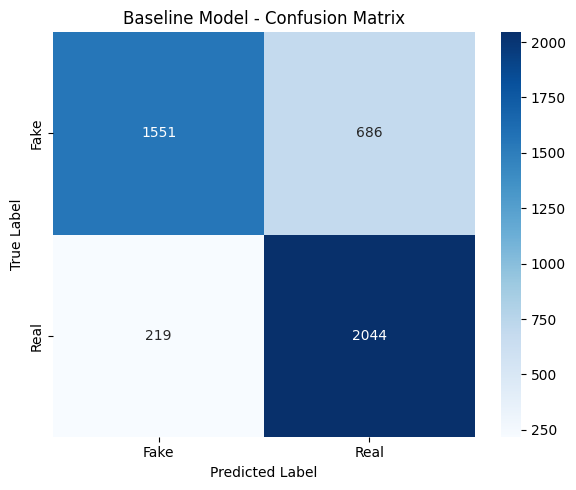

In [24]:
# Test evaluation for baseline model
baseline_model.eval()
baseline_preds = []
baseline_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = baseline_model(images)
        _, predicted = torch.max(outputs, 1)
        baseline_preds.extend(predicted.cpu().numpy())
        baseline_labels.extend(labels.cpu().numpy())

baseline_test_acc = sum(p == l for p, l in zip(baseline_preds, baseline_labels)) / len(baseline_labels)
print(f'Baseline Test Accuracy: {baseline_test_acc:.4f}')
print('\nBaseline Classification Report:')
print(classification_report(baseline_labels, baseline_preds, target_names=['Fake', 'Real']))

# Confusion matrix
cm_baseline = confusion_matrix(baseline_labels, baseline_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            cmap='Blues')
plt.title('Baseline Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{save_dir}/baseline_confusion_matrix.png')
plt.show()

In [27]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate baseline metrics
b_precision, b_recall, b_f1, _ = precision_recall_fscore_support(
    baseline_labels, baseline_preds, average=None, labels=[0, 1]
)
b_macro_f1 = precision_recall_fscore_support(
    baseline_labels, baseline_preds, average='macro'
)[2]

# Calculate best config metrics
bc_precision, bc_recall, bc_f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average=None, labels=[0, 1]
)
bc_macro_f1 = precision_recall_fscore_support(
    all_labels, all_preds, average='macro'
)[2]

# Build comparison table
comparison = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Fake Precision', 'Fake Recall',
               'Real Precision', 'Real Recall', 'F1 Macro'],
    'Baseline': [baseline_test_acc, b_precision[0], b_recall[0],
                 b_precision[1], b_recall[1], b_macro_f1],
    'Best Config': [test_acc, bc_precision[0], bc_recall[0],
                    bc_precision[1], bc_recall[1], bc_macro_f1]
})

print(comparison.round(4).to_string(index=False))

        Metric  Baseline  Best Config
 Test Accuracy    0.7989       0.8809
Fake Precision    0.8763       0.8260
   Fake Recall    0.6933       0.9633
Real Precision    0.7487       0.9566
   Real Recall    0.9032       0.7994
      F1 Macro    0.7964       0.8802


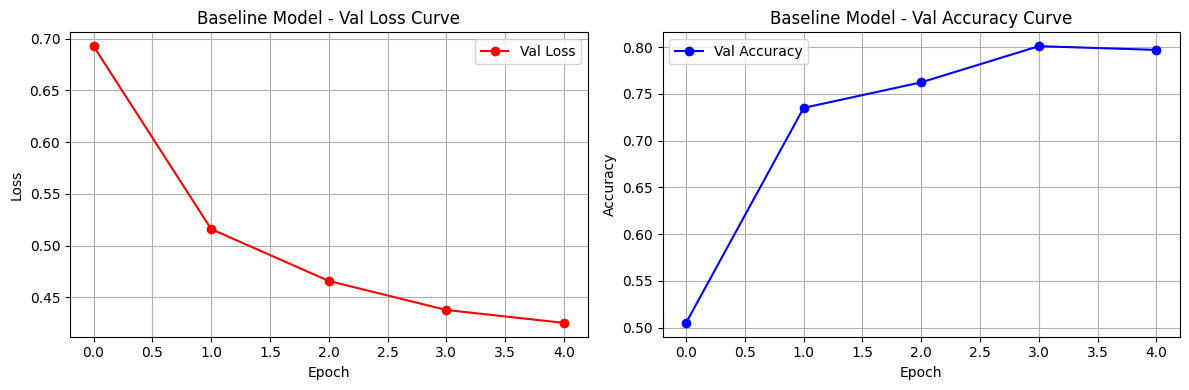

In [28]:
# Baseline g
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(baseline_result['val_loss_curve'], marker='o', color='red', label='Val Loss')
ax1.set_title('Baseline Model - Val Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(baseline_result['val_acc_curve'], marker='o', color='blue', label='Val Accuracy')
ax2.set_title('Baseline Model - Val Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/baseline_curves.png')
plt.show()